In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Human Data Analysis

### Label Distribution vis

In [2]:
df = pd.read_excel('C:/Users/administer/Desktop/BDD/magicians-transfer/data/subjects_age_sex_data_MRI.xlsx')
df.head()

,ID,Age,Sex,Dataset,Dataset-ID
0,sub-ABIDE1050339,18.0000,MALE,ABIDE,50339
1,sub-ABIDE1050701,18.0000,MALE,ABIDE,50701
2,sub-ABIDE1050445,18.1383,MALE,ABIDE,50445
3,sub-ABIDE1050459,18.1547,MALE,ABIDE,50459
4,sub-ABIDE1050341,18.2000,FEMALE,ABIDE,50341


Text(0, 0.5, 'Age')

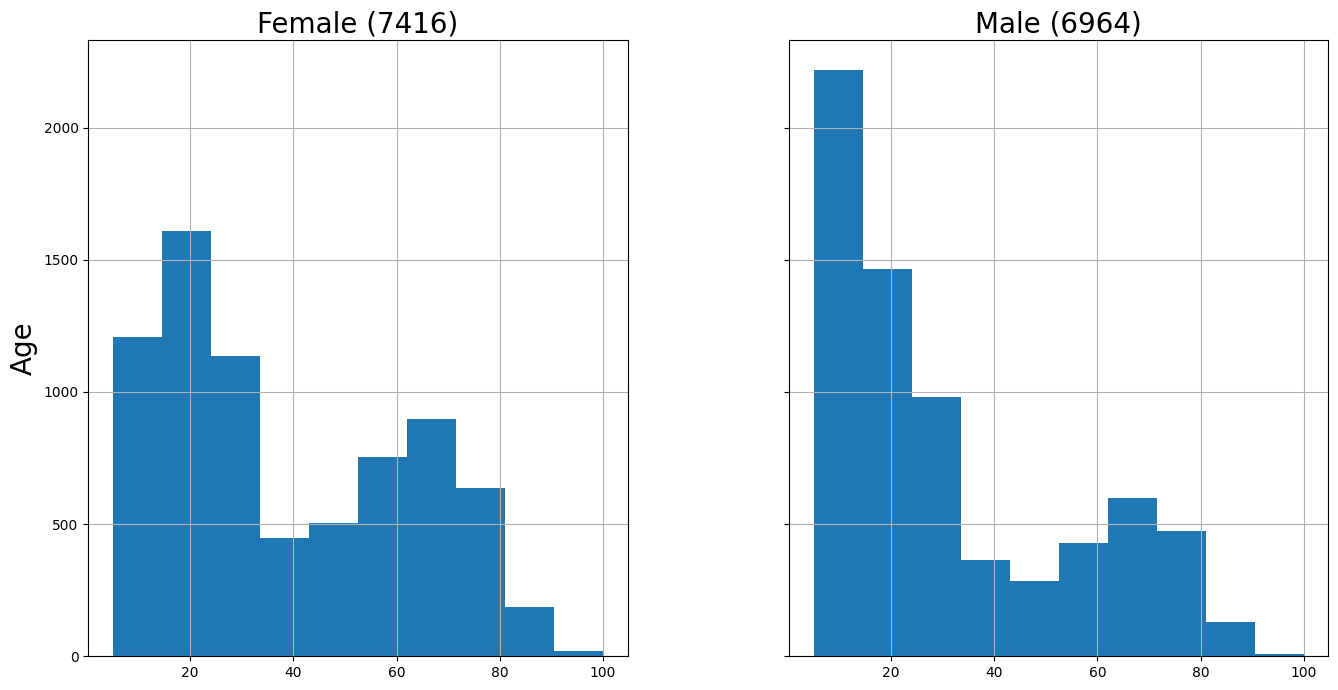

In [3]:
fig, ax = plt.subplots(1,2, figsize=(16,8), sharey=True)

total_female = len(df[df['Sex']=='FEMALE'])
total_male = len(df[df['Sex']=='MALE'])

df[df['Sex']=='FEMALE'].hist(ax=ax[0])
df[df['Sex']=='MALE'].hist(ax=ax[1])

ax[0].set_title('Female ('+str(total_female)+')', fontsize=20)
ax[1].set_title('Male ('+str(total_male)+')', fontsize=20)

ax[0].set_ylabel('Age', fontsize=20)

### Feature Normalization

In [5]:
df_human = pd.read_excel('C:/Users/administer/Desktop/BDD/magicians-transfer/data/Human.parcellated_thickness.xlsx')
df_human.head()

,Unnamed: 0,sid,Markov.1,Markov.2,Markov.3,Markov.4,Markov.5,Markov.6,Markov.7,Markov.8,...,Schaefer217.191,Schaefer217.192,Schaefer217.193,Schaefer217.194,Schaefer217.195,Schaefer217.196,Schaefer217.197,Schaefer217.198,Schaefer217.199,Schaefer217.200
0,0,sub-OAS30876MRD4592,1.995032,2.203564,1.651978,1.969754,2.603206,2.295727,2.385144,2.719692,...,8.193966,7.736098,7.404804,7.431338,7.541022,7.433447,7.475594,7.460332,7.476401,7.609443
1,1,sub-HBN_CBIC_NDARXC962XNK,2.557198,2.011555,2.175673,1.863080,2.473705,2.576267,2.392282,2.242582,...,6.927265,7.487809,7.098700,6.753360,6.841211,6.707229,7.189156,6.795299,6.823550,6.533783
2,2,sub-AOMIC_0770,2.246607,2.295872,1.978412,2.069700,2.213602,2.449572,2.541624,2.777280,...,8.117053,7.775745,7.608771,7.579930,7.573511,7.607256,7.883723,7.630075,7.670835,7.354955
3,3,sub-AOMIC_0344,2.219745,2.366237,2.036068,2.173696,2.508847,2.408997,2.430510,2.882698,...,7.908504,7.856069,7.756918,7.526684,7.410575,7.654072,7.952062,7.682724,7.444550,7.697996
4,4,sub-Narratives_150,2.131236,2.432549,2.066158,2.352589,2.331565,2.799966,2.490590,2.818574,...,8.229232,7.847060,7.821367,7.739102,8.001608,7.803380,7.750091,7.730715,7.858832,7.892026


In [13]:
df_human_normalize= {}
features = df_human.columns[2:]  # features are from the 2nd column to the last

# Z-score normalization
for feature in features:
    mean = df_human[feature].mean()
    std = df_human[feature].std()
    df_human_normalize[feature] = (df_human[feature] - mean) / std

# Save the Human normalized data
df_human_normalize = pd.DataFrame(df_human_normalize)
label_human = df_human.iloc[:, :2]
df_human_normalize = pd.concat([label_human, df_human_normalize], axis=1)
df_human_normalize.to_excel('Human_normalized_parcellated_thickness.xlsx', index=False)

In [24]:
df_human_normalize.head()

,Unnamed: 0,sid,Markov.1,Markov.2,Markov.3,Markov.4,Markov.5,Markov.6,Markov.7,Markov.8,...,Schaefer217.191,Schaefer217.192,Schaefer217.193,Schaefer217.194,Schaefer217.195,Schaefer217.196,Schaefer217.197,Schaefer217.198,Schaefer217.199,Schaefer217.200
0,0,sub-OAS30876MRD4592,-0.775549,-0.766189,-1.492595,-1.069430,0.409994,-0.885375,-0.692269,-0.248215,...,0.227526,-0.003846,-0.868252,-0.517133,-0.259262,-0.114604,-1.229259,-0.657517,-0.449849,-0.081471
1,1,sub-HBN_CBIC_NDARXC962XNK,1.488213,-1.714416,0.657214,-1.589493,-0.099156,0.098169,-0.659870,-2.209368,...,-3.831496,-0.811504,-2.050433,-3.187892,-2.774903,-2.489650,-2.257417,-3.013168,-2.996411,-4.065334
2,2,sub-AOMIC_0770,0.237506,-0.310331,-0.152561,-0.582172,-1.121780,-0.346012,0.018032,-0.011503,...,-0.018932,0.125121,-0.080524,0.068217,-0.142471,0.453828,0.235705,-0.056261,0.308574,-1.024003
3,3,sub-AOMIC_0344,0.129338,0.037164,0.084123,-0.075167,0.039011,-0.488263,-0.486341,0.421815,...,-0.687209,0.386403,0.491622,-0.141533,-0.728185,0.606935,0.481005,0.130231,-0.574091,0.246499
4,4,sub-Narratives_150,-0.227077,0.364645,0.207643,0.796980,-0.657996,0.882439,-0.213624,0.158235,...,0.340534,0.357098,0.740528,0.695244,1.396425,1.095236,-0.243962,0.300225,1.041893,0.965117


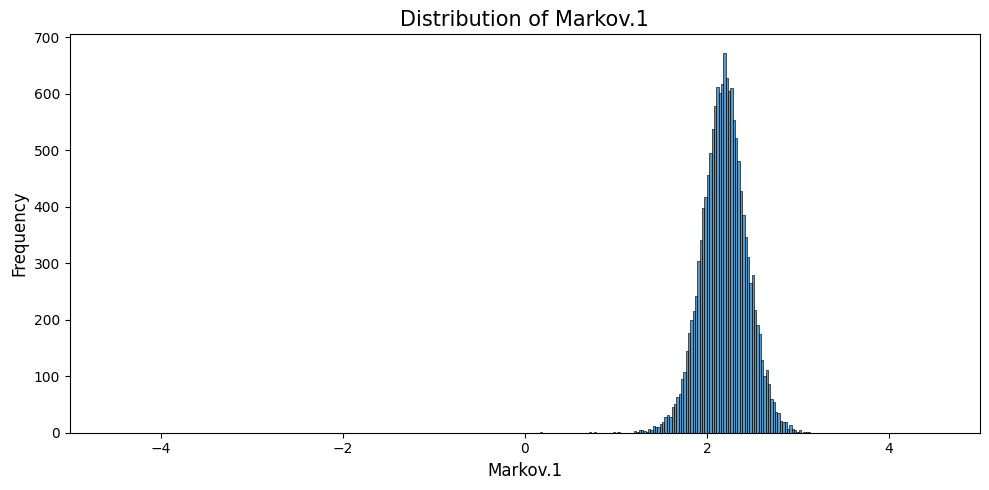

In [14]:
feature_sample = df_human.columns[2]

plt.figure(figsize=(10,5))

# histplot of the sample feature
sns.histplot(df_human[feature_sample])
plt.title(f'Distribution of {feature_sample}', fontsize=15)
plt.xlabel(feature_sample, fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(-5,5) 

plt.tight_layout()
plt.show()

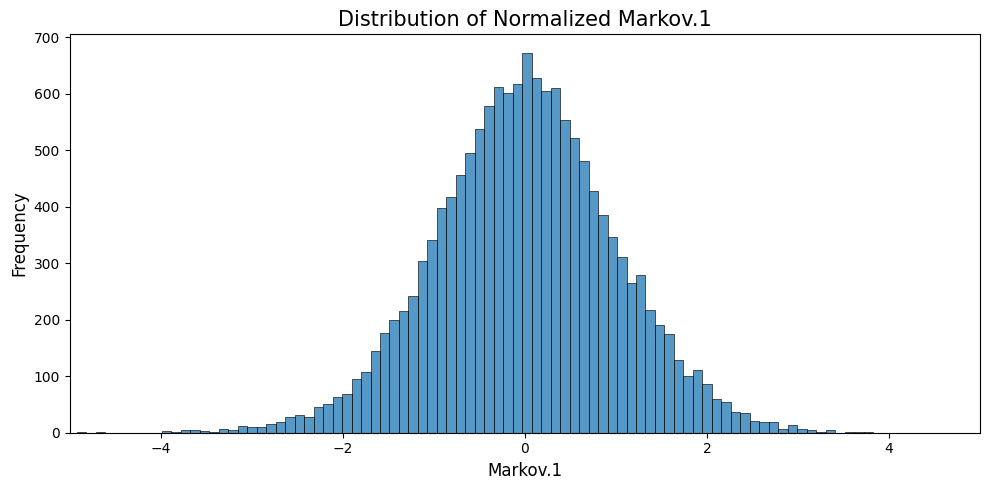

In [15]:
feature_sample = df_human_normalize.columns[2]

plt.figure(figsize=(10,5))

# histplot of the sample feature
sns.histplot(df_human_normalize[feature_sample])
plt.title(f'Distribution of Normalized {feature_sample}', fontsize=15)
plt.xlabel(feature_sample, fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(-5,5) 

plt.tight_layout()
plt.show()

## Macaque Data Analysis

In [16]:
df = pd.read_csv('C:/Users/administer/Desktop/BDD/magicians-transfer/data/uwmadison.csv')
df.head()

,participant_id,age,sex
0,sub-1001,1.756164,M
1,sub-1002,1.783562,F
2,sub-1003,1.756164,M
3,sub-1004,1.756164,M
4,sub-1005,1.742466,M


Text(0, 0.5, 'Age')

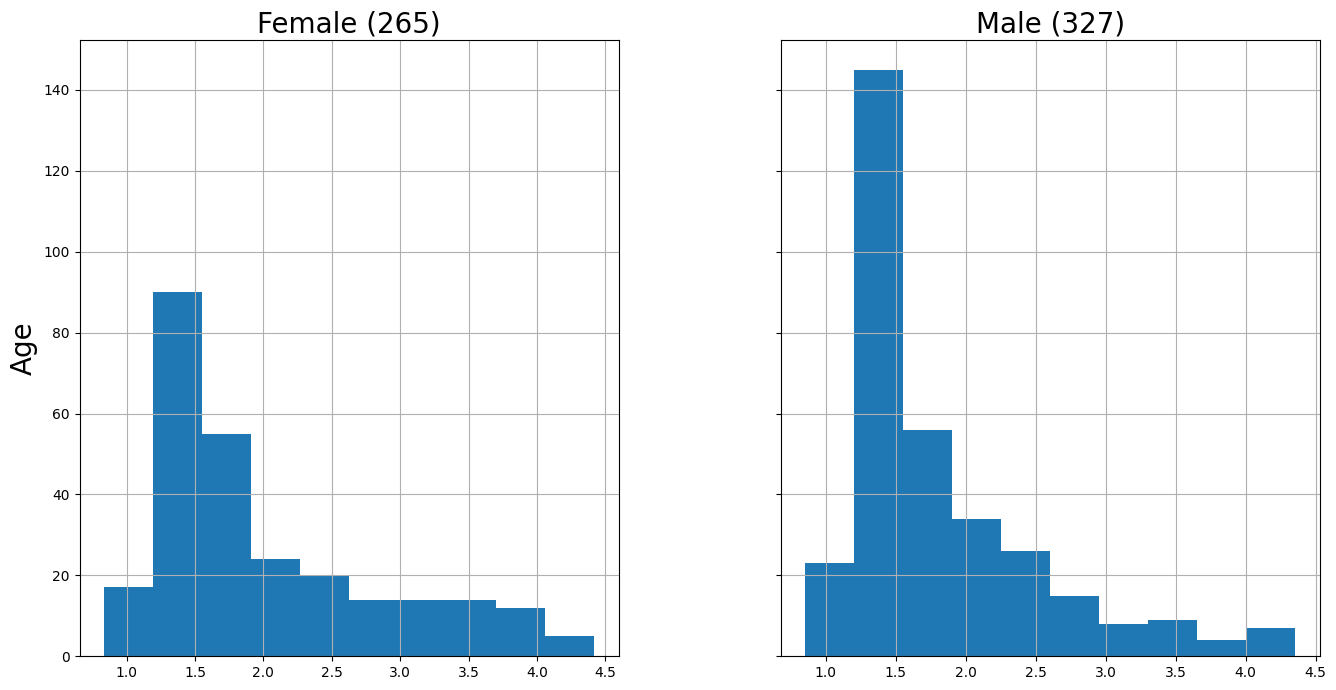

In [17]:
fig, ax = plt.subplots(1,2, figsize=(16,8), sharey=True)

total_female = len(df[df['sex']=='F'])
total_male = len(df[df['sex']=='M'])

df[df['sex']=='F'].hist(ax=ax[0])
df[df['sex']=='M'].hist(ax=ax[1])

ax[0].set_title('Female ('+str(total_female)+')', fontsize=20)
ax[1].set_title('Male ('+str(total_male)+')', fontsize=20)

ax[0].set_ylabel('Age', fontsize=20)

In [18]:
df_macaque = pd.read_excel('C:/Users/administer/Desktop/BDD/magicians-transfer/data/Macaque.parcellated_thickness.xlsx')
df_macaque.head()

,Unnamed: 0,participant_id,age,sex,Markov.1,Markov.2,Markov.3,Markov.4,Markov.5,Markov.6,...,Schaefer217.191,Schaefer217.192,Schaefer217.193,Schaefer217.194,Schaefer217.195,Schaefer217.196,Schaefer217.197,Schaefer217.198,Schaefer217.199,Schaefer217.200
0,0,sub-1001,1.756164,M,3.048436,3.908286,3.221595,3.615675,4.662432,3.707754,...,4.231826,4.908868,4.522730,2.294943,2.853976,3.406234,4.261370,4.131977,3.387978,3.451267
1,1,sub-1002,1.783562,F,3.053520,3.748308,3.043567,3.764927,4.708283,4.060617,...,4.384853,4.849508,4.589500,2.443734,2.855187,3.344378,3.926697,3.477919,2.962553,3.474969
2,2,sub-1003,1.756164,M,3.211265,4.122524,3.374628,4.022762,4.759439,4.182558,...,4.570739,4.921833,4.770724,3.106145,3.094785,3.350355,4.562199,4.212585,3.582792,3.827813
3,3,sub-1004,1.756164,M,3.004275,3.681716,3.227427,3.762712,4.555942,3.984013,...,4.264869,4.935628,4.505048,3.337418,2.892611,3.690076,4.095378,4.328465,3.763171,3.758017
4,4,sub-1005,1.742466,M,2.868796,3.837011,2.997172,3.724171,4.537298,3.816082,...,4.154663,4.817727,4.695378,3.965287,3.219764,3.268439,4.115168,3.889531,3.271547,4.040183


In [20]:
df_macaque_normalize= {}
features = df_macaque.columns[4:]  # features are from the 2nd column to the last

# Z-score normalization
for feature in features:
    mean = df_macaque[feature].mean()
    std = df_macaque[feature].std()
    df_macaque_normalize[feature] = (df_macaque[feature] - mean) / std

# Save the Human normalized data
df_macaque_normalize = pd.DataFrame(df_macaque_normalize)
label_macaque = df_macaque.iloc[:, :4]
df_macaque_normalize = pd.concat([label_macaque, df_macaque_normalize], axis=1)
df_macaque_normalize.to_excel('Macaque_normalized_parcellated_thickness.xlsx', index=False)

In [25]:
df_macaque_normalize.head()

,Unnamed: 0,participant_id,age,sex,Markov.1,Markov.2,Markov.3,Markov.4,Markov.5,Markov.6,...,Schaefer217.191,Schaefer217.192,Schaefer217.193,Schaefer217.194,Schaefer217.195,Schaefer217.196,Schaefer217.197,Schaefer217.198,Schaefer217.199,Schaefer217.200
0,0,sub-1001,1.756164,M,0.022776,0.186669,0.517615,-0.693460,0.647652,0.009852,...,-0.476449,0.964997,0.573463,-1.139774,-0.886799,0.550320,0.692718,0.850013,0.334241,-0.337606
1,1,sub-1002,1.783562,F,0.045095,-0.611675,-0.704012,0.045374,0.841457,1.283684,...,0.766879,0.207089,1.031874,-0.760713,-0.882121,0.314296,-1.065794,-1.679927,-1.244096,-0.244224
2,2,sub-1003,1.756164,M,0.737540,1.255789,1.567724,1.321717,1.057688,1.723890,...,2.277182,1.130530,2.276062,0.926858,0.042886,0.337102,2.273404,1.161811,1.057004,1.145977
3,3,sub-1004,1.756164,M,-0.171071,-0.943997,0.557631,0.034409,0.197532,1.007145,...,-0.207979,1.306663,0.452062,1.516053,-0.737640,1.633377,-0.179469,1.610042,1.726218,0.870983
4,4,sub-1005,1.742466,M,-0.765778,-0.169020,-1.022376,-0.156378,0.118726,0.400915,...,-1.103385,-0.198697,1.758774,3.115625,0.525387,0.024538,-0.075489,-0.087785,-0.097722,1.982710


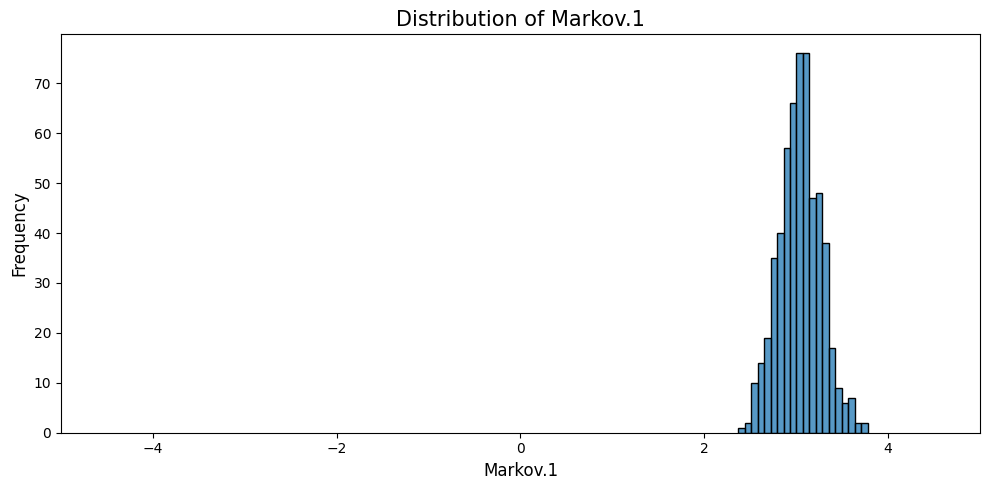

In [22]:
feature_sample = df_macaque.columns[4]

plt.figure(figsize=(10,5))

# histplot of the sample feature
sns.histplot(df_macaque[feature_sample])
plt.title(f'Distribution of {feature_sample}', fontsize=15)
plt.xlabel(feature_sample, fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(-5,5) 

plt.tight_layout()
plt.show()

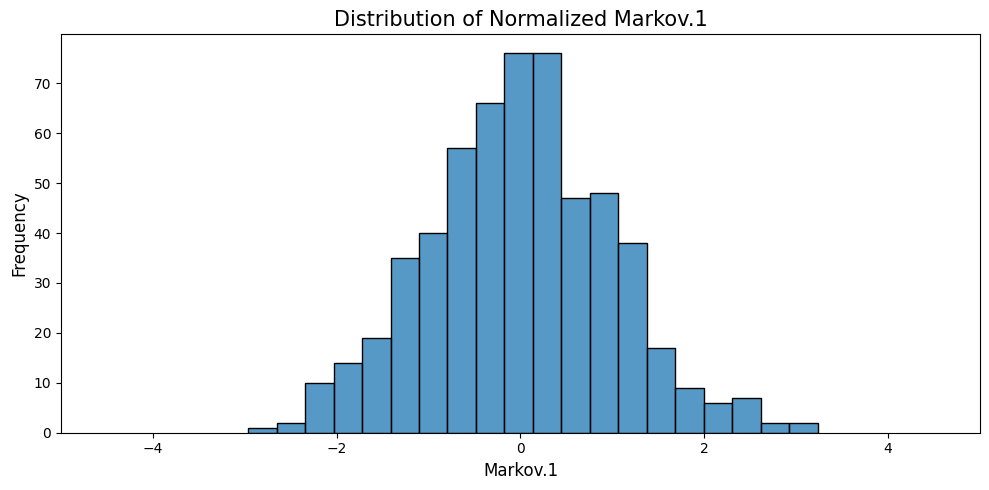

In [23]:
feature_sample = df_macaque_normalize.columns[4]

plt.figure(figsize=(10,5))

# histplot of the sample feature
sns.histplot(df_macaque_normalize[feature_sample])
plt.title(f'Distribution of Normalized {feature_sample}', fontsize=15)
plt.xlabel(feature_sample, fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(-5,5) 

plt.tight_layout()
plt.show()